## Selección de variables

### Análisis descriptivo
Con el objetivo de identificar las variables con mayor potencial predictivo, se analiza la relación entre las variables explicativas y la variable respuesta, que indica si el bateador realizó o no un swing. Para ello, se llevan a cabo análisis bivariados que permiten explorar posibles asociaciones, detectar patrones de comportamiento y evaluar la relevancia de las distintas variables para la construcción de los modelos.

In [1]:
# Cargamos los paquetes necesarios 
import matplotlib.pyplot as plt 
import polars as pl
import seaborn as sns
import numpy as np
import pyprojroot
from plotnine import *
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

In [2]:
# Definir la ruta raiz del proyecto
ROOT = pyprojroot.here()

# Cargamos los datos
datos_entrenamiento = pl.read_parquet(ROOT / "datos" / "train.parquet")

### Proporción de swings según el tipo de lanzamiento

El tipo de lanzamiento puede influir en la decisión del bateador de realizar un swing, ya que cada categoría presenta características particulares de velocidad y movimiento. Analizar la proporción de swings para cada tipo de lanzamiento permite identificar posibles diferencias en el comportamiento de los bateadores frente a las distintas alternativas ofrecidas por el pitcher.

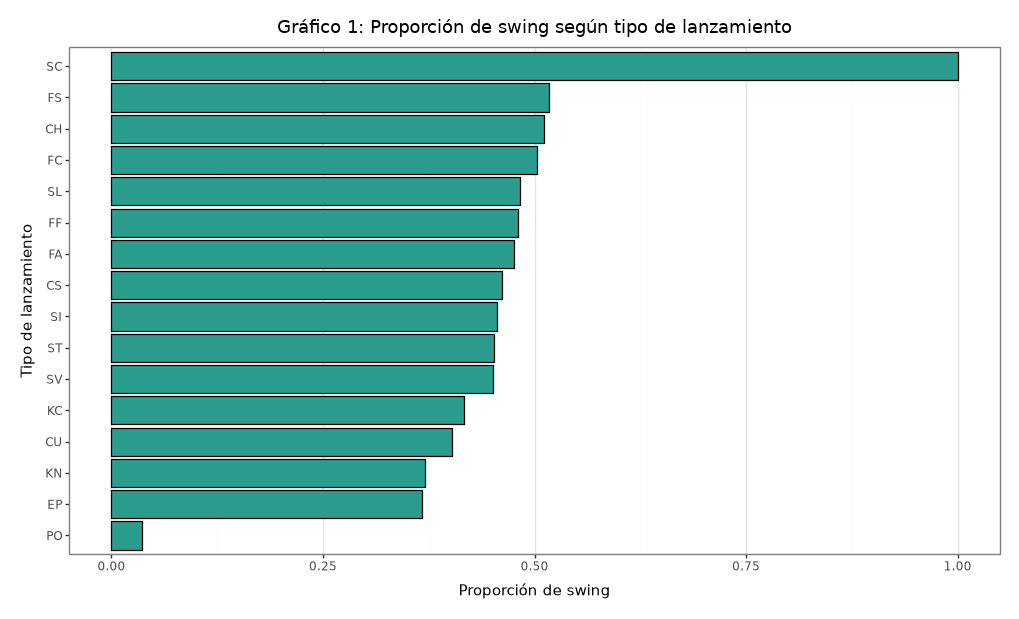

In [3]:
# Se calcula la proporción de swing según tipo de lanzamiento
swing_pitch_type = (
    datos_entrenamiento
    .filter(pl.col("pitch_type").is_not_null())
    .group_by("pitch_type")
    .agg(
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(
        swing_pitch_type,
        aes(x="pitch_type", y="proporcion_swing")
    )
    + geom_col(fill="#2A9D8F", color = "black")
    + coord_flip()
    + scale_x_discrete(
        limits=swing_pitch_type["pitch_type"].tolist()[::-1]
    )
    + labs(
        title="Gráfico 1: Proporción de swing según tipo de lanzamiento",
        x="Tipo de lanzamiento",
        y="Proporción de swing"
    )
    + theme_bw()
    + theme(
        figure_size=(10, 6),
        panel_grid_major_y=element_blank(),
        panel_grid_minor_y=element_blank()
    )
)

In [4]:
# Cantidad de swings por tipo de lanzamiento
(
    datos_entrenamiento
    .group_by("pitch_type")
    .agg(
        pl.len().alias("cantidad"),
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
)

pitch_type,cantidad,proporcion_swing
str,u32,f64
"""SC""",1,1.0
"""FS""",9044,0.51747
"""CH""",64298,0.511073
"""FC""",39453,0.502649
"""SL""",100686,0.482987
…,…,…
"""KC""",12397,0.416956
"""CU""",43206,0.401842
"""KN""",54,0.37037


Tanto en el gráfico como en la tabla presentados anteriormente, se puede notar que la proporción de swings varía entre los distintos tipos de lanzamiento, con valores que, excluyendo las categorías `SC` y `PO`, se encuentran aproximadamente entre 0,38 y 0,52. Si bien varias categorías presentan proporciones similares, se observan diferencias de hasta 14 puntos porcentuales entre algunos tipos de lanzamiento, lo que sugiere que esta variable podría estar asociada con la decisión del bateador de realizar un swing.

Las categorías `SC` y `PO` presentan proporciones extremas; sin embargo, estos resultados deben interpretarse con cuidado, ya que corresponden a tipos de lanzamiento con un número muy reducido de observaciones (1 y 28, respectivamente), por lo que sus proporciones no resultan representativas.

#### Proporción de swing según posición del bateador

Evaluar la proporción de swings permite identificar si existen diferencias de comportamiento según la ubicación del bateador, ya que esta característica puede influir en la estrategia de juego y en la decisión de realizar un swing frente a un lanzamiento.

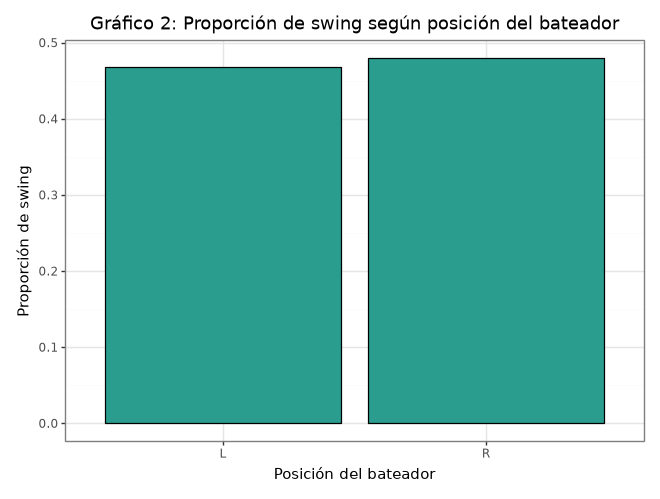

In [5]:
# Se calcula la proporción de swing según posición del bateador
swing_stand = (
    datos_entrenamiento
    .filter(pl.col("stand").is_not_null())
    .group_by("stand")
    .agg(
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(
        swing_stand,
        aes(x="stand", y="proporcion_swing")
    )
    + geom_col(fill="#2A9D8F", color = "black")
    + labs(
        title="Gráfico 2: Proporción de swing según posición del bateador",
        x="Posición del bateador",
        y="Proporción de swing"
    )
    + theme_bw()
)

Se observa una distribución muy similar entre bateadores derechos e izquierdos, con una proporción de swings aproximada de 0.45 en ambos grupos. La ausencia de diferencias marcadas sugiere que la posición del bateador no tendría una influencia importante sobre la ocurrencia de un swing.

#### Proporción de swing según mano del pitcher

La mano del pitcher es una característica relevante a analizar, ya que puede influir en la estrategia del bateador y en la forma en que enfrenta un lanzamiento. Por este motivo, estudiar la proporción de swings permite observar si existen diferencias de comportamiento frente a lanzadores derechos o zurdos.

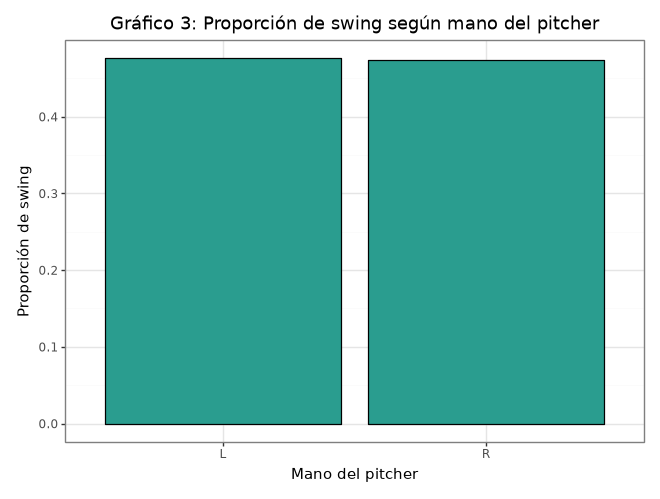

In [6]:
# Se calcula la proporción de swing según mano del pitcher
swing_pthrows = (
    datos_entrenamiento
    .filter(pl.col("p_throws").is_not_null())
    .group_by("p_throws")
    .agg(
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
    .to_pandas()
)
# Se arma el gráfico
(
    ggplot(
        swing_pthrows,
        aes(x="p_throws", y="proporcion_swing")
    )
    + geom_col(fill="#2A9D8F", color = "black")
    + labs(
        title="Gráfico 3: Proporción de swing según mano del pitcher",
        x="Mano del pitcher",
        y="Proporción de swing"
    )
    + theme_bw()
)

De manera similar a lo observado para la posición del bateador, la distribución de la proporción de swings según la mano del pitcher es prácticamente la misma entre categorías. La ausencia de diferencias permite suponer que esta variable no muestra una relación evidente con la ocurrencia de un swing.

#### Relación entre variables cuantitativas contínuas y la intención del swing



Con el objetivo de identificar posibles relaciones entre las variables cuantitativas continuas y la intención de swing, se construye un panel de boxplots que permite comparar la distribución de cada predictor en función de la variable respuesta. Esta visualización facilita la detección de diferencias entre grupos y la identificación de variables relevantes para el modelo a proponer.

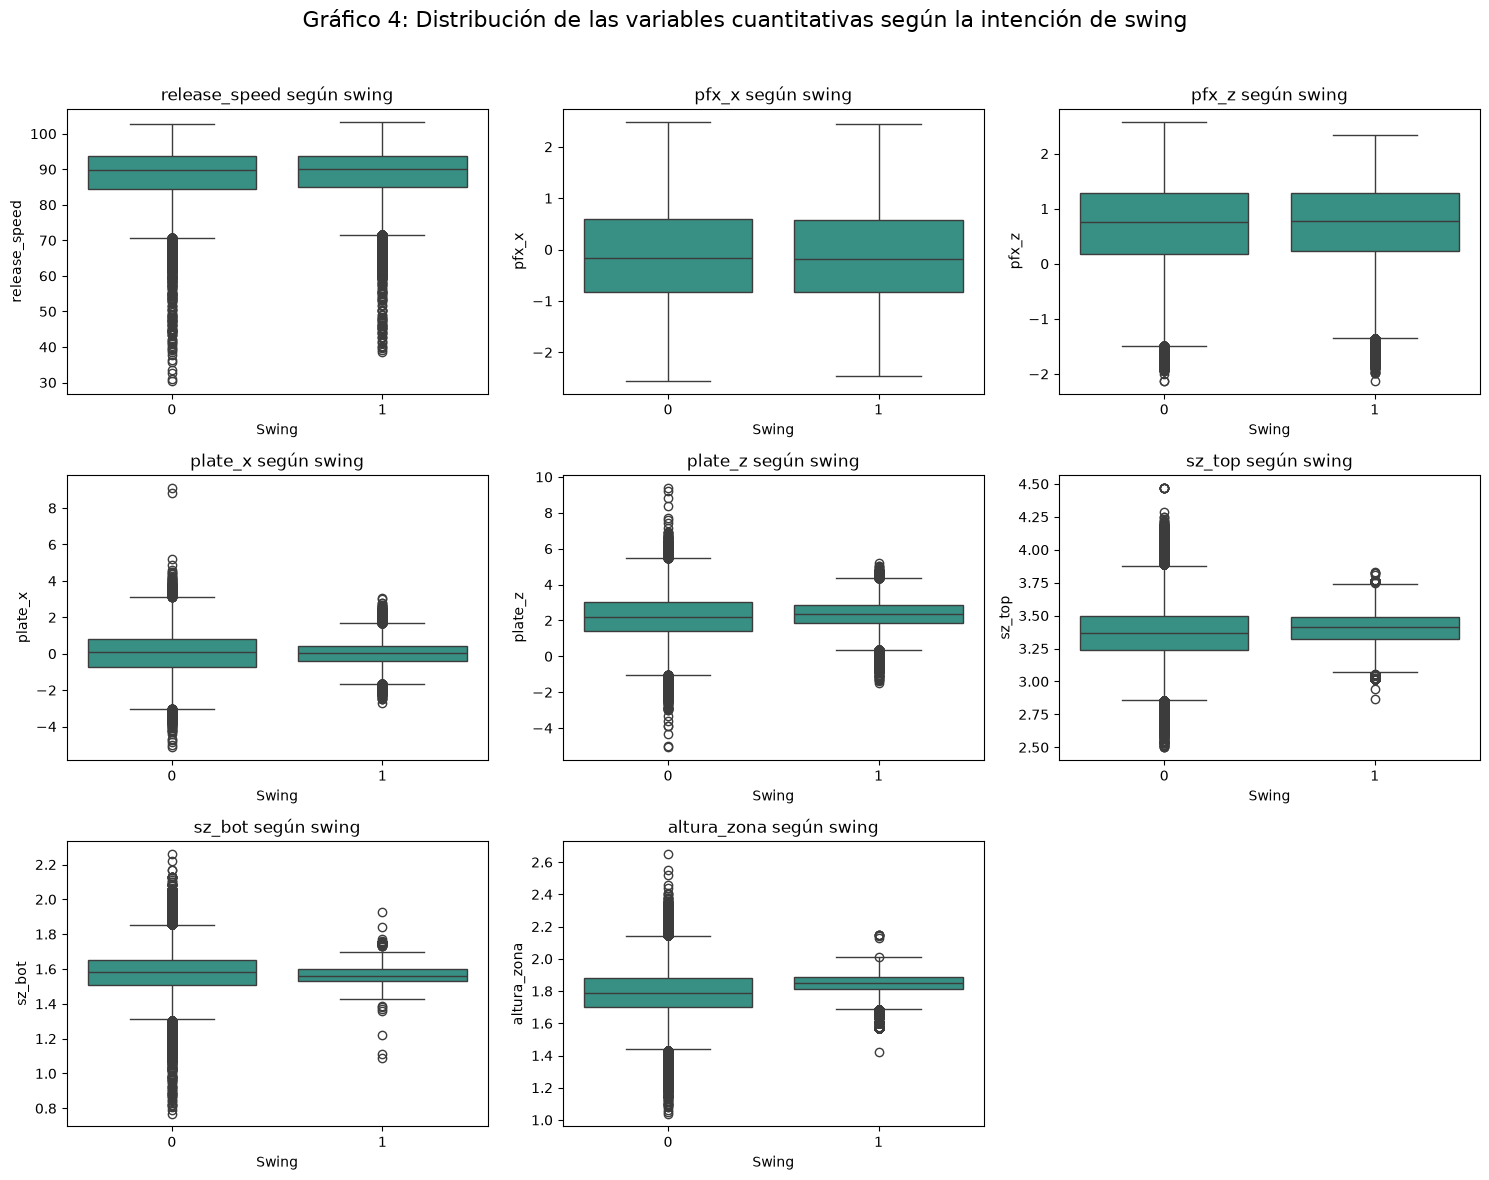

In [7]:
# Se seleccionan las variables cuantitativas continuas del conjunto de datos
variables_continuas = [
    "release_speed",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot",
    "altura_zona"
]

# Se arma el panel de gráficos
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, variable in enumerate(variables_continuas):
    sns.boxplot(
        data=datos_entrenamiento,
        x="swing",
        y=variable,
        color="#2A9D8F",
        ax=axes[i]
    )

    axes[i].set_title(f"{variable} según swing")
    axes[i].set_xlabel("Swing")
    axes[i].set_ylabel(variable)

# Eliminar espacios vacíos si quedan gráficos sin usar
for j in range(len(variables_continuas), len(axes)):
    axes[j].remove()

# Título general
fig.suptitle(
    "Gráfico 4: Distribución de las variables cuantitativas según la intención de swing",
    fontsize=16
)

# Dejar espacio para el título
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


A partir del panel de boxplots se observa que las variables `release_speed`, `pfx_x` y `pfx_z` presentan distribuciones muy similares entre los grupos con y sin swing, lo que sugiere una capacidad limitada para discriminar entre ambas categorías de la variable respuesta.

Por otro lado, las variables `plate_x`, `plate_z`, `sz_top`, `sz_bot` y `altura_zona` muestran algunas diferencias en sus medianas y niveles de dispersión. En el caso de `plate_x`, se observa una menor dispersión para los lanzamientos en los que el bateador realiza swing, mientras que para `plate_z` se aprecia un leve desplazamiento de la distribución hacia valores más altos cuando ocurre un swing.

Asimismo, las variables `sz_top` y `sz_bot`, que representan los límites superior e inferior de la zona de strike respectivamente, muestran cambios tanto en la dispersión como en la ubicación de sus distribuciones entre los grupos. En particular, para los lanzamientos con swing se observan distribuciones más concentradas y una menor presencia de valores extremos.

Por otro lado, la altura de la zona de strike, la cual es representada por la diferencia entre `sz_top` y `sz_bot`, presenta diferencias en cuanto a la dispersión si se evalúa la intención de swing. Esto también se observa para la mediana.

En los boxplots se observa la presencia de valores atípicos, principalmente en las observaciones correspondientes a lanzamientos en los que el bateador no realiza un swing. Sin embargo, se decidió no imputar ni eliminar estos valores, ya que representan una proporción muy reducida respecto del total de observaciones y, por lo tanto, es poco probable que ejerzan una influencia significativa sobre el análisis.

En conjunto, los resultados indican que las variables relacionadas con la ubicación espacial de la pelota y con la definición de la zona de strike presentan una mayor capacidad para diferenciar entre situaciones con y sin swing, por lo que podrían ser consideradas como variables relevantes.

#### Relación entre las variables cuantitativas discretas y la intención de swing
Para las variables cuantitativas discretas se utilizan gráficos de barras para analizar su relación con la intención de swing.

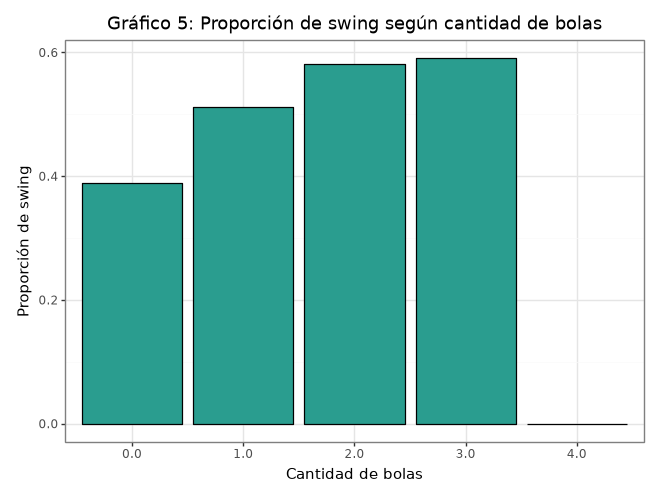

In [10]:
datos_pd = datos_entrenamiento.to_pandas()
# Se calcula la proporción de swing por cantidad de bolas
balls_swing = (
    datos_pd
    .groupby("balls", as_index=False)
    ["swing"]
    .mean()
)

# Se arma el gráfico
(
    ggplot(balls_swing, aes(x="factor(balls)", y="swing"))
    + geom_col(
        fill="#2A9D8F",
        color="black"
    )
    + labs(
        title="Gráfico 5: Proporción de swing según cantidad de bolas",
        x="Cantidad de bolas",
        y="Proporción de swing"
    )
    + theme_bw()
)

En el gráfico se observa una tendencia creciente entre la proporción de swings y la cantidad de bolas, es decir que la proporción de swings aumenta a medida que aumenta la cantidad de bolas. Sin embargo, el caso de 4 bolas se presenta un comportamiento atípico, con una proporción de swings cercana a cero. Esto se debe a que, al alcanzar cuatro bolas, el bateador obtiene la base por bolas y el turno termina, por lo que ya no existe un lanzamiento posterior sobre el cual pueda decidir realizar un swing.

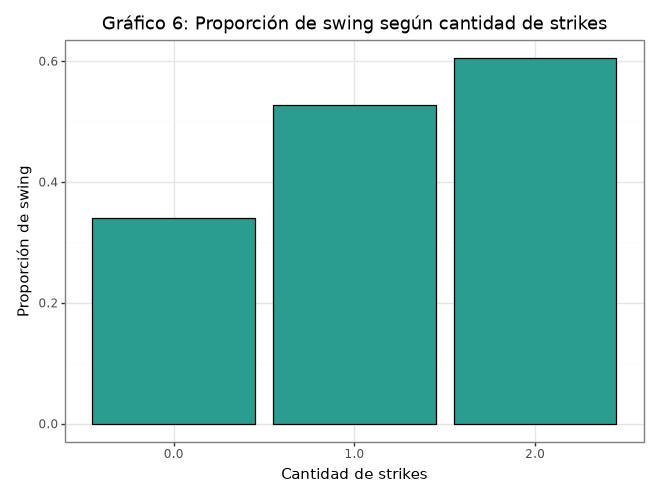

In [11]:
# Se calcula la proporción de swing según la cantidad de strikes
strikes_swing = (
    datos_pd
    .groupby("strikes", as_index=False)
    ["swing"]
    .mean()
)

# Se arma el gráfico
(
    ggplot(strikes_swing, aes(x="factor(strikes)", y="swing"))
    + geom_col(
        fill="#2A9D8F",
        color="black"
    )
    + labs(
        title="Gráfico 6: Proporción de swing según cantidad de strikes",
        x="Cantidad de strikes",
        y="Proporción de swing"
    )
    + theme_bw()
)

En el anterior gráfico, se observa que la proporción de swings aumenta a medida que incrementa la cantidad de strikes en la cuenta. Esto indica que, a medida que el bateador se encuentra más cerca de quedar eliminado, aumenta su intención de realizar un swing para intentar continuar en el turno.

Luego de realizar el análisis bivariado para ver aquellas variables que resultan potenciales predictoras del modelo, las seleccionadas fueron:
- `pitch_type`
- `plate_x` 
- `plate_z`
- `altura_zona`
- `balls`
- `strikes`
- `release_speed`

La variable `release_speed` no presentó diferencias marcadas entre las observaciones con y sin swing en el análisis bivariado, por lo que su efecto marginal sobre la decisión del bateador parece limitado. Sin embargo, se decidió incorporarla como variable candidata debido a su relevancia dentro del dominio del problema. La velocidad del lanzamiento no tiene necesariamente un efecto constante, sino que su influencia puede depender del tipo de lanzamiento realizado. 

Dado que `sz_bot`y `sz_top`, estaban muy correlacionadas, se deja en el modelo solo `altura_zona`, la cual resume la información contenida en esas dos variables. Esto se hace para evitar futuros problemas de multicolinealidad.

### Métodos de selección de variables

Si bien el análisis descriptivo realizado previamente permite identificar variables que podrían resultar relevantes para explicar la ocurrencia de un swing (como `balls`, `strike`, `plate_x`, `plate_z`, entre otras), las conclusiones obtenidas en esta etapa son principalmente exploratorias. Por este motivo, se aplican métodos de selección de variables con el objetivo de evaluar de manera más objetiva la contribución de cada predictor y determinar cuáles aportan información relevante para la construcción de los modelos predictivos dentro del subconjunto ya elegido. 

#### Preparación de los datos

Con el objetivo de aplicar métodos de selección basados en penalización, las variables categóricas se transforman mediante One-Hot Encoding (Creación de variables dummies). 

Debido a que el método LASSO depende de la escala de los predictores, las variables numéricas fueron estandarizadas mediante la transformación Z-score. Luego de la transformación, las variables presentan medias aproximadamente iguales a cero y desvíos estándar cercanos a uno, asegurando una contribución comparable de cada predictor dentro del modelo penalizado.

In [12]:

variables_cuantitativas = [
    "release_speed",
    "balls",
    "strikes",
    "plate_x",
    "plate_z",
    "altura_zona"
]

variables_categoricas = [
    "pitch_type"
]

predictores = variables_cuantitativas + variables_categoricas

In [13]:
X = datos_entrenamiento.select(predictores).to_pandas()
# Convertimos a dummies las variables categoricas
X = pd.get_dummies(
    X,
    columns=variables_categoricas,
    drop_first=True
)

In [14]:
#ESTANDARIZACIÓN
scaler = StandardScaler()

X[variables_cuantitativas] = scaler.fit_transform(
    X[variables_cuantitativas]
)

X[variables_cuantitativas].describe()

,release_speed,balls,strikes,plate_x,plate_z,altura_zona
count,5.678810e+05,5.678810e+05,5.678810e+05,5.678810e+05,5.678810e+05,5.678810e+05
mean,2.517650e-15,-2.122065e-17,-6.836653e-17,1.156125e-17,-2.021968e-17,1.004978e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-9.662920e+00,-9.129713e-01,-1.080775e+00,-6.124620e+00,-7.462710e+00,-7.071211e+00
25%,-7.020857e-01,-9.129713e-01,-1.080775e+00,-6.778131e-01,-6.451280e-01,-3.464059e-01
50%,1.741588e-01,1.200317e-01,1.264065e-01,-4.346742e-03,5.133212e-03,1.988493e-01
75%,8.024085e-01,1.153035e+00,1.333588e+00,6.691197e-01,6.553945e-01,5.623531e-01
max,2.406101e+00,3.219041e+00,1.333588e+00,1.071204e+01,7.229129e+00,7.559788e+00


#### Regresión LASSO

Se utiliza una regresión logística con regularización LASSO, la cual permite controlar la complejidad del modelo mediante la penalización de los coeficientes. En este modelo se incluyen los términos de interacción de segundo orden.

La principal ventaja de este enfoque es que, además de estimar la relación entre los predictores y la variable respuesta, realiza una selección implícita de variables al llevar algunos coeficientes exactamente a cero. Por lo tanto, las variables con coeficientes no nulos son consideradas relevantes para explicar la probabilidad de swing y serán utilizadas posteriormente en la construcción de los modelos predictivos.


In [15]:

# Variable respuesta 
y = datos_entrenamiento["swing"]

# Crear interacciones únicamente entre las predictoras seleccionadas
poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_inter = poly.fit_transform(X)

# Nombres de las variables generadas
nombres_variables = poly.get_feature_names_out(X.columns)

# Modelo LASSO
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=1000
)

lasso.fit(X_inter, y)


C:\Users\vicky\TP2_python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
C:\Users\vicky\TP2_python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the

Se obtienen los coeficientes del modelo de regresión LASSO.

In [16]:
# Coeficientes
coeficientes = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": lasso.coef_[0]
})


coeficientes

,Variable,Coeficiente
0,release_speed,0.037925
1,balls,0.169700
2,strikes,0.356923
3,plate_x,0.048231
4,plate_z,0.463055
...,...,...
226,pitch_type_SI pitch_type_ST,0.000000
227,pitch_type_SI pitch_type_SV,0.000000
228,pitch_type_SL pitch_type_ST,0.000000
229,pitch_type_SL pitch_type_SV,0.000000


Luego, se descartan aquellos coeficientes nulos.

In [17]:
# Conservar solo las variables seleccionadas
variables_seleccionadas = (
    coeficientes
    .query("Coeficiente != 0")
    .assign(
        Importancia=lambda x: x["Coeficiente"].abs()
    )
    .sort_values(
        "Importancia",
        ascending=False
    )
)
variables_seleccionadas

,Variable,Coeficiente,Importancia
105,plate_z pitch_type_PO,-1.115838,1.115838
114,altura_zona pitch_type_FA,-1.069503,1.069503
5,altura_zona,0.777094,0.777094
113,altura_zona pitch_type_EP,-0.591575,0.591575
101,plate_z pitch_type_FF,-0.551133,0.551133
...,...,...,...
124,altura_zona pitch_type_ST,0.004315,0.004315
25,release_speed altura_zona,0.002982,0.002982
21,release_speed balls,-0.001190,0.001190
67,strikes pitch_type_FC,0.001025,0.001025


Se contruye una tabla en la cual se ordenan las variables que deben ser incorporadas en el modelo según su importancia.

Dado que las variables explicativas fueron previamente estandarizadas, la importancia de cada una se evaluó mediante el valor absoluto de su coeficiente estimado por el modelo de regresión logística. La estandarización permite comparar directamente la magnitud de los coeficientes, ya que todas las variables se encuentran expresadas en la misma escala. De este modo, valores absolutos mayores indican una mayor influencia de la variable sobre la respuesta.

In [18]:
variables_seleccionadas = (
    variables_seleccionadas
    .assign(
        importancia=lambda x: abs(x["Coeficiente"])
    )
    .sort_values(
        "importancia",
        ascending=False
    )
)

variables_seleccionadas

,Variable,Coeficiente,Importancia,importancia
105,plate_z pitch_type_PO,-1.115838,1.115838,1.115838
114,altura_zona pitch_type_FA,-1.069503,1.069503,1.069503
5,altura_zona,0.777094,0.777094,0.777094
113,altura_zona pitch_type_EP,-0.591575,0.591575,0.591575
101,plate_z pitch_type_FF,-0.551133,0.551133,0.551133
...,...,...,...,...
124,altura_zona pitch_type_ST,0.004315,0.004315,0.004315
25,release_speed altura_zona,0.002982,0.002982,0.002982
21,release_speed balls,-0.001190,0.001190,0.001190
67,strikes pitch_type_FC,0.001025,0.001025,0.001025


Como las categorías de las variables cualitativas aparecen como dummies, se vuelven a agrupar para poder trabajar con la variable original. Para esto, se construye una función que te devuelve las variables nuevamente agrupadas.

In [19]:
def variable_original(nombre):

    # Si es una interacción
    if " " in nombre:
        variables = nombre.split(" ")
        variables = [variable_original(v) for v in variables]
        return " × ".join(variables)

    # Variables dummy
    if nombre.startswith("pitch_type_"):
        return "pitch_type"
    elif nombre.startswith("stand_"):
        return "stand"
    elif nombre.startswith("p_throws_"):
        return "p_throws"
    else:
        return nombre

Finalmente, se seleccionan los primeros 15 términos más signficativos.

In [20]:
variables_seleccionadas["Variable_original"] = (
    variables_seleccionadas["Variable"]
    .apply(variable_original)
)

lasso_resumen = (
    variables_seleccionadas
    .groupby("Variable_original")
    .agg(
        Coeficiente=("Coeficiente", lambda x: x.abs().max())
    )
    .reset_index()
    .sort_values(
        "Coeficiente",
        ascending=False
    )
)

lasso_resumen

,Variable_original,Coeficiente
15,plate_z × pitch_type,1.115838
1,altura_zona × pitch_type,1.069503
0,altura_zona,0.777094
13,plate_z,0.463055
23,strikes,0.356923
8,pitch_type,0.352711
19,release_speed × pitch_type,0.281640
11,plate_x × pitch_type,0.209052
12,plate_x × plate_z,0.206429
4,balls × pitch_type,0.188239


### Selección final

Los resultados obtenidos mediante LASSO muestran que las interacciones más importantes involucran principalmente a la variable `pitch_type`, lo que indica que el efecto del tipo de lanzamiento sobre la decisión de realizar un swing depende de otras características del pitcheo, como la ubicación y la velocidad.

La interacción con mayor importancia es `plate_z × pitch_type`, lo que indica que el efecto de la altura del lanzamiento sobre la probabilidad de swing cambia según el tipo de lanzamiento realizado. De forma similar, `altura_zona × pitch_type` muestra que la influencia de la altura de la zona de strike depende del tipo de pitcheo, ya que un mismo lanzamiento puede ser interpretado de manera diferente según sus características.

Por otro lado, la interacción `release_speed × pitch_type` indica que la velocidad no tiene el mismo efecto para todos los lanzamientos. Esto resulta esperable, ya que una misma velocidad puede representar diferentes niveles de dificultad dependiendo de si el lanzamiento es una recta, slider, cambio de velocidad u otro tipo de pitcheo.

Además, la interacción `plate_x × pitch_type` muestra que la ubicación horizontal del lanzamiento también tiene un efecto diferente según el tipo de lanzamiento. La interacción `plate_x × plate_z` indica que la decisión del bateador depende de la ubicación conjunta del lanzamiento, considerando tanto su posición horizontal como vertical.

En cuanto a los efectos principales, se conservan las variables `altura_zona`, `plate_x`, `plate_z`, `pitch_type`, `release_speed`, `balls` y `strikes`, ya que presentan importancia dentro del modelo y permiten explicar distintos aspectos de la decisión de swing. Además, al incluir interacciones, se mantienen sus efectos principales siguiendo el principio de jerarquía del modelo.

Por lo tanto, el modelo final queda compuesto por estos siete efectos principales y las siguientes interacciones:

- `altura_zona × pitch_type`
- `plate_z × pitch_type`
- `release_speed × pitch_type` 
- `plate_x × pitch_type`
- `plate_x × plate_z`

El resto de las interacciones fueron descartadas debido a que presentaban coeficientes más bajos y aumentaban la complejidad del modelo sin aportar una mejora clara en la interpretación. De esta manera, se obtiene un modelo más simple, manteniendo las variables con mayor aporte predictivo y una interpretación coherente con la situación de un turno al bate.